Initial parameters:
[0.47945912 4.9003743  2.75460644 4.54566578 6.14488933 3.38346934
 3.14863273 0.45271062 1.68665186 3.14085438]

Initial cost:
-0.17562214199507328

Checking gradient at initial point:

PSR gradient:
[ 1.23517595  1.71519413  1.72567495 -0.33013835  0.01451635 -2.4069297
  1.32544959 -0.48512911 -0.79098668  2.10975347]

Numerical gradient:
[ 1.23517595  1.71519413  1.72567495 -0.33013835  0.01451635 -2.4069297
  1.32544959 -0.48512911 -0.79098668  2.10975347]

Difference:
[ 3.75761644e-10 -1.82083459e-10 -5.74488457e-10  3.84030974e-10
 -3.63470171e-10  3.00015124e-10 -4.43598491e-10 -5.34483569e-11
 -3.47419538e-10 -4.20026680e-10]


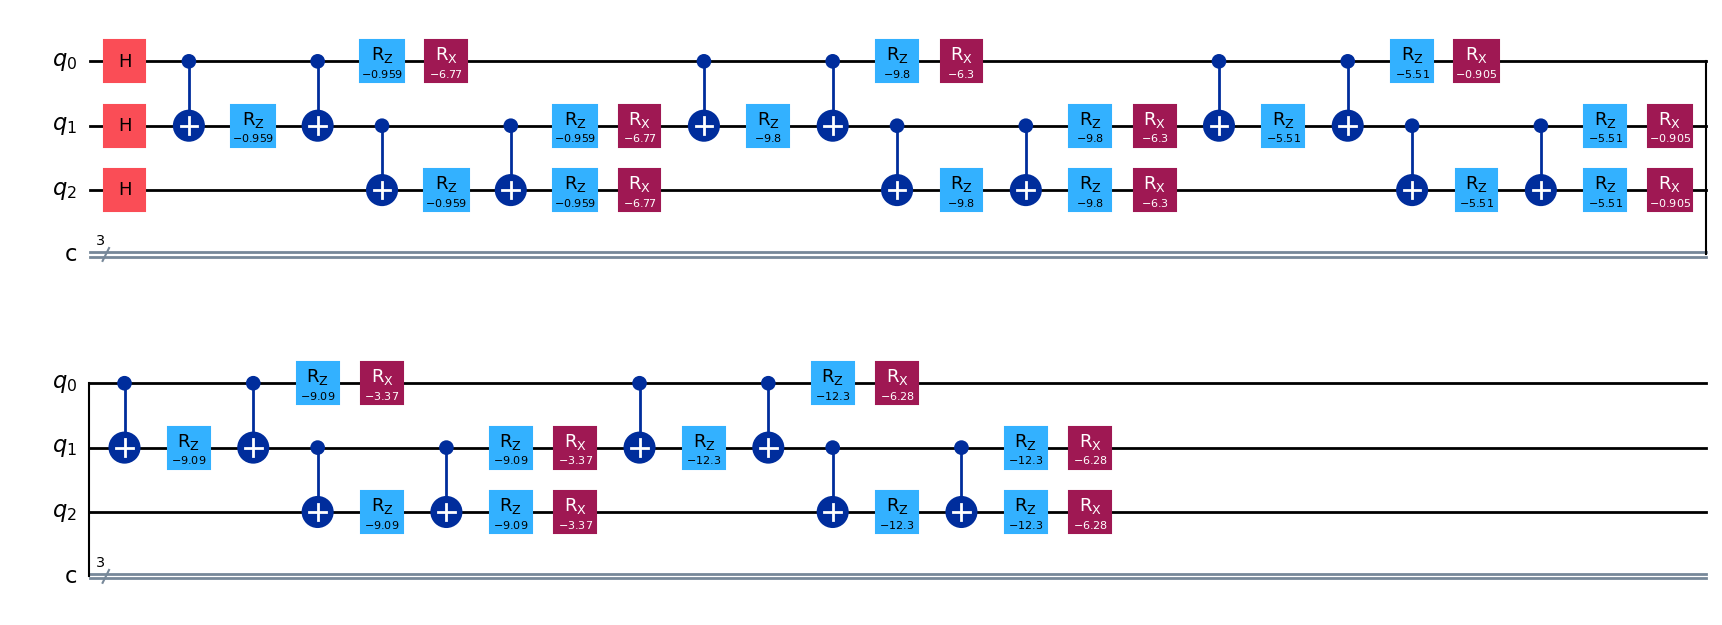

Epoch   0 | Cost = -0.17562214 | Grad norm = 4.51850680
Epoch  10 | Cost = -1.64016083 | Grad norm = 4.25648696
Epoch  20 | Cost = -3.72141522 | Grad norm = 4.11085329
Epoch  30 | Cost = -4.61397460 | Grad norm = 2.14564354
Epoch  40 | Cost = -4.88089310 | Grad norm = 1.00090372
Epoch  50 | Cost = -4.92674061 | Grad norm = 0.38560377
Epoch  60 | Cost = -4.93527593 | Grad norm = 0.22403117
Epoch  70 | Cost = -4.93958296 | Grad norm = 0.19839236
Epoch  80 | Cost = -4.94349790 | Grad norm = 0.19872742
Epoch  90 | Cost = -4.94752022 | Grad norm = 0.20268086
Epoch 100 | Cost = -4.95170175 | Grad norm = 0.20630043
Epoch 110 | Cost = -4.95600734 | Grad norm = 0.20852182
Epoch 120 | Cost = -4.96036820 | Grad norm = 0.20878435
Epoch 130 | Cost = -4.96469499 | Grad norm = 0.20672524
Epoch 140 | Cost = -4.96888849 | Grad norm = 0.20218998
Epoch 150 | Cost = -4.97285251 | Grad norm = 0.19526451
Epoch 160 | Cost = -4.97650677 | Grad norm = 0.18626596
Epoch 170 | Cost = -4.97979638 | Grad norm = 0.1

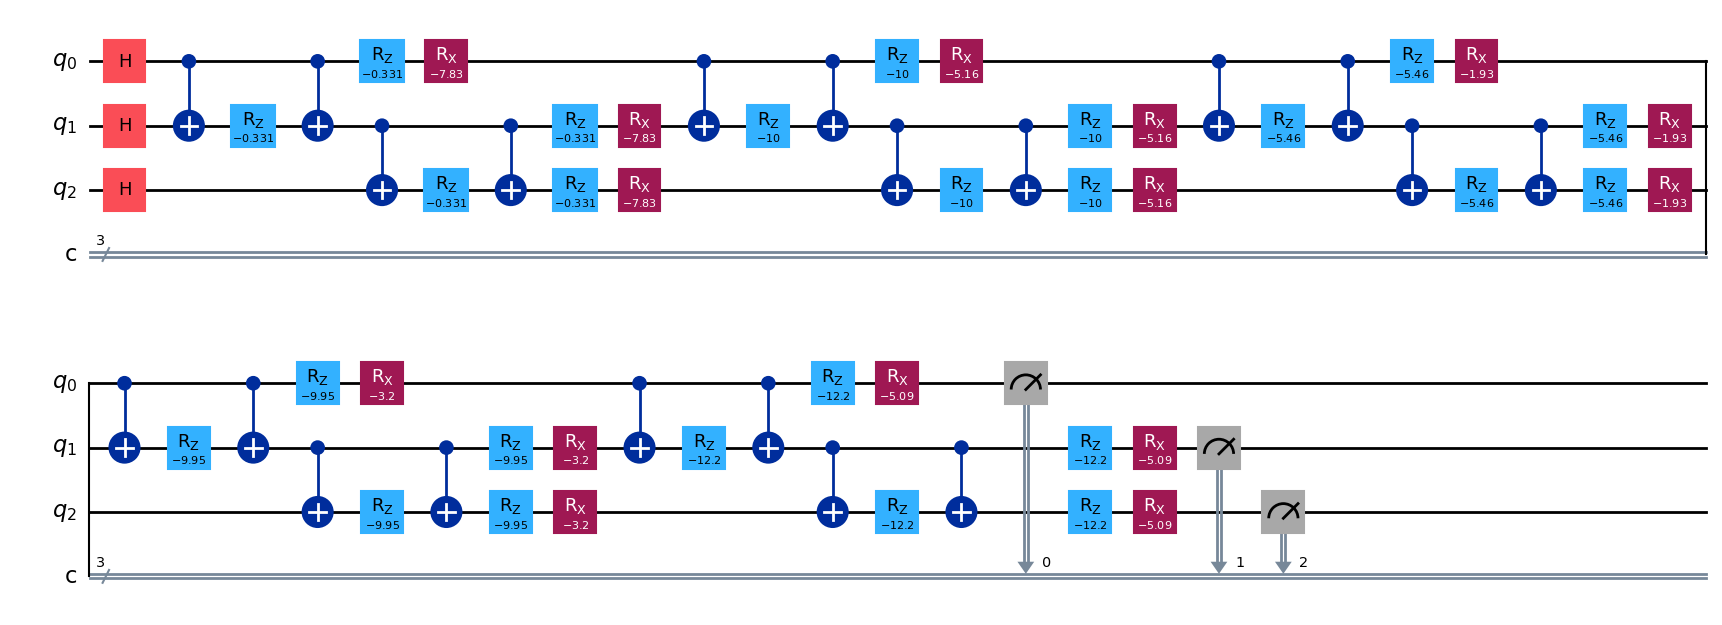


Measurement counts:
{'000': 2048}


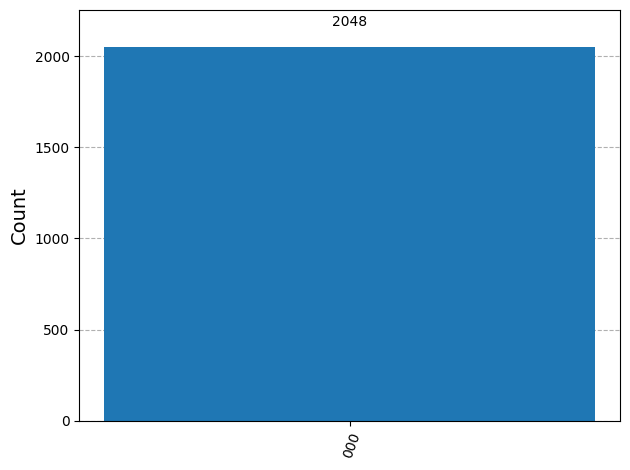

In [ ]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from IPython.display import display
from numpy import pi
from qiskit_aer import AerSimulator
import numpy as np

# User choices

n = 3
p = 5
shots = 2048

epochs = 300
lr = 0.01

# h_i values
# Hc = - sum Zi Zi+1 - sum hi Zi
h = [1.0, 1.0, 1.0]

# Basic matrices

I = np.array([[1, 0],
              [0, 1]], dtype=complex)

Z = np.array([[1, 0],
              [0, -1]], dtype=complex)


# Tensor product of many matrices
# Example: kron_all([Z, I, Z]) = Z tensor I tensor Z

def kron_all(op_list):
    result = op_list[0]

    for op in op_list[1:]:
        result = np.kron(result, op)

    return result

# Single Z operator on qubit q
#
# Important:
# Qiskit qubit 0 is the rightmost tensor factor.
#
# So for n = 3:
# q = 0 means I tensor I tensor Z
# q = 1 means I tensor Z tensor I
# q = 2 means Z tensor I tensor I

def Z_on_qubit(q):
    ops = []

    for position in range(n):
        if position == n - 1 - q:
            ops.append(Z)
        else:
            ops.append(I)

    return kron_all(ops)

# ZZ operator on qubits q and q+1
#
# Example for n = 3:
# q = 0 means Z0 Z1 = I tensor Z tensor Z
# q = 1 means Z1 Z2 = Z tensor Z tensor I

def ZZ_on_pair(q):
    ops = []

    for position in range(n):
        if position == n - 1 - q or position == n - 1 - (q + 1):
            ops.append(Z)
        else:
            ops.append(I)

    return kron_all(ops)

# Build Hc matrix:
#
# Hc = - sum Zi Zi+1 - sum hi Zi

Hc = np.zeros((2**n, 2**n), dtype=complex)

# Add -Zi Zi+1 terms
for q in range(n - 1):
    Hc = Hc - ZZ_on_pair(q)

# Add -hi Zi terms
for q in range(n):
    Hc = Hc - h[q] * Z_on_qubit(q)

# Cost from statevector
#
# C = <psi|Hc|psi>

def cost_from_statevector(state):
    psi = state.data

    value = np.vdot(psi, Hc @ psi)

    return np.real(value)

# Normal cost layer
#
# Hc = - sum Zi Zi+1 - sum hi Zi
#
# Uc(gamma) = exp(-i gamma Hc)
#           = exp(+i gamma sum Zi Zi+1)
#             exp(+i gamma sum hi Zi)

def apply_cost_layer(qc, gamma):

    # Pair terms: exp(+i gamma Zi Zi+1)
    for q in range(n - 1):
        qc.cx(q, q + 1)
        qc.rz(-2 * gamma, q + 1)
        qc.cx(q, q + 1)

    # Field terms: exp(+i gamma hi Zi)
    for q in range(n):
        qc.rz(-2 * gamma * h[q], q)


# Mixer layer
#
# Hm = - sum Xi
#
# Um(beta) = exp(-i beta Hm)
#          = exp(+i beta sum Xi)
#
# exp(+i beta X) = Rx(-2 beta)

def apply_mixer_layer(qc, beta):
    for q in range(n):
        qc.rx(-2 * beta, q)

# Build ordinary QAOA circuit
#
# params = [gamma1, gamma2, ..., gammap, beta1, beta2, ..., betap]

def build_qaoa_circuit(params, measure=False):
    gammas = params[:p]
    betas = params[p:]

    qr = QuantumRegister(n, "q")
    cr = ClassicalRegister(n, "c")
    qc = QuantumCircuit(qr, cr)

    # Initial state = |+> tensor |+> tensor ... tensor |+>
    qc.h(qr)

    for layer in range(p):
        apply_cost_layer(qc, gammas[layer])
        apply_mixer_layer(qc, betas[layer])

    if measure:
        qc.measure(qr, cr)

    return qc

# Ordinary cost function

def cost_function(params):
    qc = build_qaoa_circuit(params, measure=False)

    state = Statevector.from_instruction(qc)

    return cost_from_statevector(state)

# Shifted cost-layer functions for PSR of gamma


# Cost layer with one cost gate shifted
#
# term_type = "ZZ" or "Z"
#
# For "ZZ":
#     term_index = q means Zq Z(q+1)
#
# For "Z":
#     term_index = q means Zq
#
# alpha_shifted is the shifted angle inside:
#     exp(+i alpha P)
#
# For ZZ term:
#     alpha = gamma
#
# For Z field term:
#     alpha = gamma * h[q]

def apply_cost_layer_with_one_gate_shifted(
    qc,
    gamma,
    term_type,
    term_index,
    alpha_shifted
):

    # Pair ZZ terms
    for q in range(n - 1):

        if term_type == "ZZ" and term_index == q:
            alpha = alpha_shifted
        else:
            alpha = gamma

        qc.cx(q, q + 1)
        qc.rz(-2 * alpha, q + 1)
        qc.cx(q, q + 1)

    # Single Z field terms
    for q in range(n):

        if term_type == "Z" and term_index == q:
            alpha = alpha_shifted
        else:
            alpha = gamma * h[q]

        qc.rz(-2 * alpha, q)


# Build circuit with one cost gate shifted

def build_qaoa_circuit_one_cost_gate_shifted(
    params,
    layer_to_shift,
    term_type,
    term_index,
    alpha_shifted
):
    gammas = params[:p]
    betas = params[p:]

    qr = QuantumRegister(n, "q")
    qc = QuantumCircuit(qr)

    qc.h(qr)

    for layer in range(p):

        if layer == layer_to_shift:
            apply_cost_layer_with_one_gate_shifted(
                qc,
                gamma=gammas[layer],
                term_type=term_type,
                term_index=term_index,
                alpha_shifted=alpha_shifted
            )
        else:
            apply_cost_layer(qc, gammas[layer])

        apply_mixer_layer(qc, betas[layer])

    return qc


# Cost with one cost gate shifted

def cost_with_one_cost_gate_shifted(
    params,
    layer_to_shift,
    term_type,
    term_index,
    alpha_shifted
):
    qc = build_qaoa_circuit_one_cost_gate_shifted(
        params,
        layer_to_shift,
        term_type,
        term_index,
        alpha_shifted
    )

    state = Statevector.from_instruction(qc)

    return cost_from_statevector(state)


# Shifted mixer-layer functions for PSR of beta

# Mixer layer with one Rx gate shifted

def apply_mixer_layer_with_one_qubit_shifted(
    qc,
    beta,
    qubit_to_shift,
    shifted_beta
):
    for q in range(n):
        if q == qubit_to_shift:
            qc.rx(-2 * shifted_beta, q)
        else:
            qc.rx(-2 * beta, q)



# Build circuit with one mixer Rx gate shifted

def build_qaoa_circuit_one_mixer_gate_shifted(
    params,
    layer_to_shift,
    qubit_to_shift,
    shifted_beta
):
    gammas = params[:p]
    betas = params[p:]

    qr = QuantumRegister(n, "q")
    qc = QuantumCircuit(qr)

    qc.h(qr)

    for layer in range(p):
        apply_cost_layer(qc, gammas[layer])

        if layer == layer_to_shift:
            apply_mixer_layer_with_one_qubit_shifted(
                qc,
                beta=betas[layer],
                qubit_to_shift=qubit_to_shift,
                shifted_beta=shifted_beta
            )
        else:
            apply_mixer_layer(qc, betas[layer])

    return qc


# Cost with one mixer Rx gate shifted

def cost_with_one_mixer_gate_shifted(
    params,
    layer_to_shift,
    qubit_to_shift,
    shifted_beta
):
    qc = build_qaoa_circuit_one_mixer_gate_shifted(
        params,
        layer_to_shift,
        qubit_to_shift,
        shifted_beta
    )

    state = Statevector.from_instruction(qc)

    return cost_from_statevector(state)


# Correct PSR gradient

def gradient_psr(params):
    grad = np.zeros_like(params)

    shift = pi / 4

    # Gamma gradients
    #
    # gamma_k appears in many cost gates:
    #
    # 1. ZZ gates:
    #    exp(+i gamma_k Zi Zi+1)
    #
    # 2. Z gates:
    #    exp(+i gamma_k hi Zi)
    #
    # So shift each gate one by one and sum.

    for i in range(p):

        layer = i
        gamma = params[i]

        total = 0.0

        # ZZ terms
        # alpha = gamma
        
        for pair_index in range(n - 1):

            plus_cost = cost_with_one_cost_gate_shifted(
                params=params,
                layer_to_shift=layer,
                term_type="ZZ",
                term_index=pair_index,
                alpha_shifted=gamma + shift
            )

            minus_cost = cost_with_one_cost_gate_shifted(
                params=params,
                layer_to_shift=layer,
                term_type="ZZ",
                term_index=pair_index,
                alpha_shifted=gamma - shift
            )

            total = total + (plus_cost - minus_cost)

       
        # Z field terms
        #
        # alpha = gamma * h[q]
        #
        # dC/dgamma = h[q] dC/dalpha
        
        for q in range(n):

            coeff = h[q]

            if coeff == 0:
                continue

            alpha = gamma * coeff

            plus_cost = cost_with_one_cost_gate_shifted(
                params=params,
                layer_to_shift=layer,
                term_type="Z",
                term_index=q,
                alpha_shifted=alpha + shift
            )

            minus_cost = cost_with_one_cost_gate_shifted(
                params=params,
                layer_to_shift=layer,
                term_type="Z",
                term_index=q,
                alpha_shifted=alpha - shift
            )

            total = total + coeff * (plus_cost - minus_cost)

        grad[i] = total

    
    # Beta gradients
    #
    # beta_k appears in n mixer gates:
    #
    # Rx(-2 beta_k) on every qubit.
    #
    # Shift one Rx gate at a time and sum.
    
    for i in range(p, 2 * p):

        layer = i - p
        beta = params[i]

        total = 0.0

        for q in range(n):

            plus_cost = cost_with_one_mixer_gate_shifted(
                params=params,
                layer_to_shift=layer,
                qubit_to_shift=q,
                shifted_beta=beta + shift
            )

            minus_cost = cost_with_one_mixer_gate_shifted(
                params=params,
                layer_to_shift=layer,
                qubit_to_shift=q,
                shifted_beta=beta - shift
            )

            total = total + (plus_cost - minus_cost)

        grad[i] = total

    return grad

# Numerical finite-difference gradient for checking

def gradient_numerical(params, eps=1e-6):
    grad = np.zeros_like(params)

    for i in range(len(params)):
        plus = params.copy()
        minus = params.copy()

        plus[i] = plus[i] + eps
        minus[i] = minus[i] - eps

        grad[i] = (cost_function(plus) - cost_function(minus)) / (2 * eps)

    return grad



# Initialize parameters

np.random.seed(7)

params = np.random.uniform(0, 2 * pi, 2 * p)

print("Initial parameters:")
print(params)

print("\nInitial cost:")
print(cost_function(params))


# Check PSR gradient vs numerical gradient

print("\nChecking gradient at initial point:")

g_psr = gradient_psr(params)
g_num = gradient_numerical(params)

print("\nPSR gradient:")
print(g_psr)

print("\nNumerical gradient:")
print(g_num)

print("\nDifference:")
print(g_psr - g_num)


# Show initial circuit

initial_qc = build_qaoa_circuit(params, measure=False)
display(initial_qc.draw(output="mpl"))


# Gradient descent

cost_history = []

for epoch in range(epochs):

    cost = cost_function(params)
    cost_history.append(cost)

    grad = gradient_psr(params)

    params = params - lr * grad

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Cost = {cost:.8f} | "
            f"Grad norm = {np.linalg.norm(grad):.8f}"
        )


print("\nFinal parameters:")
print(params)

print("\nFinal cost:")
print(cost_function(params))



# Final circuit with measurement

final_qc = build_qaoa_circuit(params, measure=True)
display(final_qc.draw(output="mpl"))



# Measurement simulation

sim = AerSimulator()

result = sim.run(final_qc, shots=shots).result()

counts = result.get_counts()

print("\nMeasurement counts:")
print(counts)

display(plot_histogram(counts))